# 04 - Correlation Matrices Analysis and Eigendecomposition

In this notebook we perform a comprehensive analysis of correlation matrices stored in `corr_windows_tensor.pt`, including:
- **Correlation value distribution analysis**: Examining the statistical properties of all pairwise correlations across all time windows
- **Eigendecomposition**: Computing eigenvalues and eigenvectors for each correlation matrix

## Correlation Values Analysis

We extract and analyze all unique correlation values from the upper triangular part of each correlation matrix. This provides insights into:
- The overall correlation structure of the asset market
- Distribution of positive vs. negative correlations
- Temporal evolution of correlation patterns

## Eigendecomposition of Correlation Matrices

The eigendecomposition of correlation matrices provides insights into the principal components (principal correlations) of the asset market and their evolution over time.

For a symmetric correlation matrix $C \in \mathbb{R}^{n \times n}$, we compute:
- $\lambda_i$: eigenvalues (sorted in descending order)
- $v_i$: corresponding eigenvectors

The explained variance ratio for the $k$-th eigenvalue is:
$$
\text{EV}_k = \frac{\lambda_k}{\sum_{i=1}^{n} \lambda_i}
$$

This helps us understand which principal correlations dominate the market structure and how many principal components are needed to explain the variance in the correlation matrix.

In [105]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

# Global matrix selection for all analyses in this notebook
# Options:
#   - 'all': use all windows
#   - integer (0 to num_windows-1): use one window
#   - 'start:stop' (e.g., '0:100'): use a window range
selected_corr_matrix = "0:1199"

## Section 1: Load Correlation Matrices Dataset

Load the correlation matrices dataset from the saved PyTorch file and extract all components needed for eigendecomposition analysis.

In [106]:
# Load the correlation matrices tensor
TENSOR_PATH = Path('../data/processed/corr_windows_tensor.pt')

# Load the saved data
checkpoint = torch.load(TENSOR_PATH)

# Extract components
corr_tensor = checkpoint['corr_tensor']
window_ranges = checkpoint['window_ranges']
window_length = checkpoint['window_length']
stride = checkpoint['stride']
tickers = checkpoint['tickers']

# Extract dimensions
num_windows = corr_tensor.shape[0]
num_assets = corr_tensor.shape[1]

print(f'Tensor loaded from: {TENSOR_PATH.resolve()}')
print('\n--- Loaded Data Structure ---')
print(f"corr_tensor shape: {corr_tensor.shape}")
print(f"  - Dimension 0 (num_windows): {corr_tensor.shape[0]} rolling windows")
print(f"  - Dimension 1 (num_assets): {corr_tensor.shape[1]} assets")
print(f"  - Dimension 2 (num_assets): {corr_tensor.shape[2]} assets (symmetric matrix)")
print(f"window_length: {window_length} days per window")
print(f"stride: {stride} days between consecutive windows")
print(f"num_tickers: {len(tickers)} tickers")
print(f"tickers (first 5): {tickers[:5]}")
print(f"window_ranges (first 3): {window_ranges[:3]}")
print(f"window_ranges (last 3): {window_ranges[-3:]}")

Tensor loaded from: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\corr_windows_tensor.pt

--- Loaded Data Structure ---
corr_tensor shape: torch.Size([1199, 333, 333])
  - Dimension 0 (num_windows): 1199 rolling windows
  - Dimension 1 (num_assets): 333 assets
  - Dimension 2 (num_assets): 333 assets (symmetric matrix)
window_length: 60 days per window
stride: 1 days between consecutive windows
num_tickers: 333 tickers
tickers (first 5): ['BBY', 'CSCO', 'TSN', 'KMI', 'GT']
window_ranges (first 3): [(0, 60), (1, 61), (2, 62)]
window_ranges (last 3): [(1196, 1256), (1197, 1257), (1198, 1258)]


## Section 2: Correlation Matrices Analysis
### Property 1: The distribution of pairwise correlations is significantly shifted towards positive values

Extract all correlation values from the matrices and analyze their distribution using histograms and statistics.

--- Correlation Values Statistics (Windows 0:1199) ---

Total number of correlation values: 66278322
Mean correlation: 0.2474
Std deviation: 0.4910
Min correlation: -0.9823
Max correlation: 0.9987
Median correlation: 0.3370

Correlation sign distribution:
  Positive (> 0): 45590812 (68.79%)
  Negative (< 0): 20687510 (31.21%)
  Zero (= 0): 0 (0.00%)


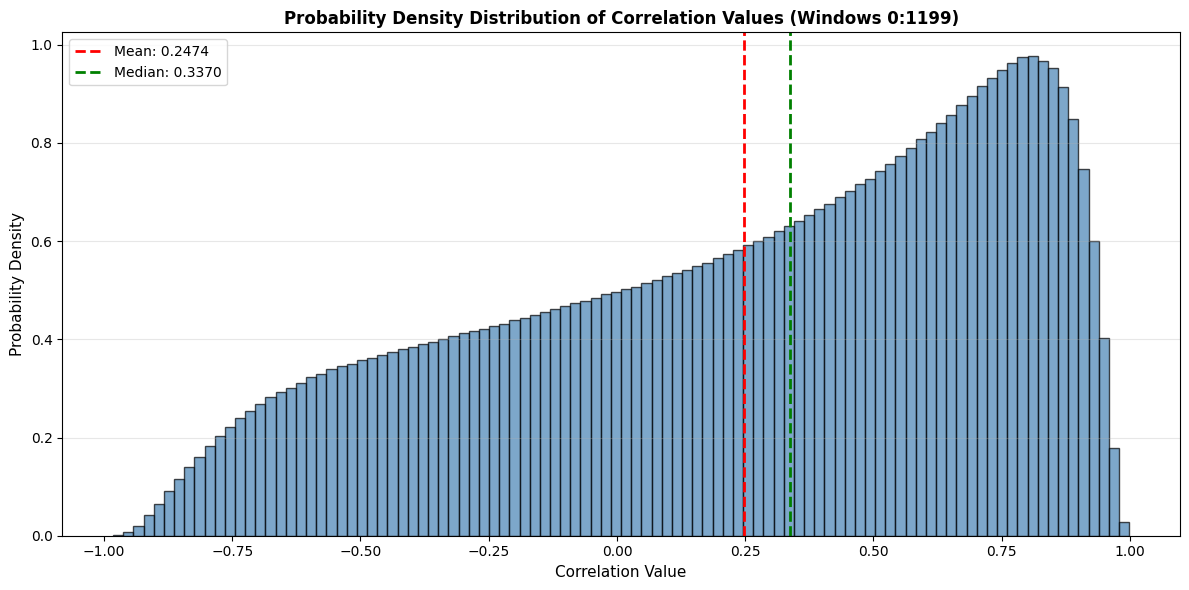


✓ Correlation value probability density visualization complete!


In [107]:
# Extract correlation values from the tensor
# We'll take the upper triangular part (excluding diagonal) to avoid duplicates

# Extract upper triangular indices (excluding diagonal)
triu_indices = torch.triu_indices(num_assets, num_assets, offset=1)
all_corr_values = []

if selected_corr_matrix == 'all':
    selected_indices = np.arange(num_windows)
    corr_title = 'All Windows'
elif isinstance(selected_corr_matrix, str) and ':' in selected_corr_matrix:
    start_str, stop_str = selected_corr_matrix.split(':')
    start_idx, stop_idx = int(start_str), int(stop_str)
    if not (0 <= start_idx < stop_idx <= num_windows):
        raise ValueError(f"Invalid selected_corr_matrix range: {selected_corr_matrix}. Expected 'start:stop' with 0 <= start < stop <= {num_windows}.")
    selected_indices = np.arange(start_idx, stop_idx)
    corr_title = f'Windows {start_idx}:{stop_idx}'
else:
    matrix_idx = int(selected_corr_matrix)
    if not (0 <= matrix_idx < num_windows):
        raise ValueError(f"Invalid selected_corr_matrix index: {matrix_idx}. Valid range is [0, {num_windows - 1}].")
    selected_indices = np.array([matrix_idx])
    corr_title = f'Matrix {matrix_idx}'

for i in selected_indices:
    corr_matrix = corr_tensor[i]
    # Get all unique correlation values (upper triangular part)
    corr_values = corr_matrix[triu_indices[0], triu_indices[1]]
    all_corr_values.append(corr_values)

# Concatenate all correlation values
all_corr_values_flat = torch.cat(all_corr_values)

print(f"--- Correlation Values Statistics ({corr_title}) ---\n")
print(f"Total number of correlation values: {len(all_corr_values_flat)}")
print(f"Mean correlation: {torch.mean(all_corr_values_flat):.4f}")
print(f"Std deviation: {torch.std(all_corr_values_flat):.4f}")
print(f"Min correlation: {torch.min(all_corr_values_flat):.4f}")
print(f"Max correlation: {torch.max(all_corr_values_flat):.4f}")
print(f"Median correlation: {torch.median(all_corr_values_flat):.4f}")

# Count positive and negative correlations
positive_corrs = torch.sum(all_corr_values_flat > 0).item()
negative_corrs = torch.sum(all_corr_values_flat < 0).item()
zero_corrs = torch.sum(all_corr_values_flat == 0).item()

print(f"\nCorrelation sign distribution:")
print(f"  Positive (> 0): {positive_corrs} ({100*positive_corrs/len(all_corr_values_flat):.2f}%)")
print(f"  Negative (< 0): {negative_corrs} ({100*negative_corrs/len(all_corr_values_flat):.2f}%)")
print(f"  Zero (= 0): {zero_corrs} ({100*zero_corrs/len(all_corr_values_flat):.2f}%)")

# Visualization of correlation values as probability density
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of all correlation values with normalized density
ax.hist(all_corr_values_flat.numpy(), bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(torch.mean(all_corr_values_flat).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(all_corr_values_flat):.4f}')
ax.axvline(torch.median(all_corr_values_flat).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(all_corr_values_flat):.4f}')
ax.set_xlabel('Correlation Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title(f'Probability Density Distribution of Correlation Values ({corr_title})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Correlation value probability density visualization complete!")

### Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues

For each correlation matrix, compute eigenvalues and eigenvectors using `torch.linalg.eigh()`. This function returns eigenvalues in ascending order.

In [108]:
# Compute eigenvalues and eigenvectors for each correlation matrix
num_windows = corr_tensor.shape[0]
num_assets = corr_tensor.shape[1]

eigenvalues_list = []
eigenvectors_list = []

print(f"Computing eigendecomposition for {num_windows} correlation matrices...")

for i in range(num_windows):
    # Get the i-th correlation matrix
    corr_matrix = corr_tensor[i]
    
    # Compute eigenvalues and eigenvectors
    # torch.linalg.eigh returns eigenvalues in ascending order
    evals, evecs = torch.linalg.eigh(corr_matrix)
    
    # Reverse to get descending order (highest eigenvalues first)
    evals = torch.flip(evals, dims=[0])
    evecs = torch.flip(evecs, dims=[1])
    
    eigenvalues_list.append(evals)
    eigenvectors_list.append(evecs)
    
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{num_windows} windows")

# Convert lists to tensors
eigenvalues_tensor = torch.stack(eigenvalues_list, dim=0)  # Shape: (num_windows, num_assets)
eigenvectors_tensor = torch.stack(eigenvectors_list, dim=0)  # Shape: (num_windows, num_assets, num_assets)

print(f"\n✓ Eigendecomposition complete!")
print(f"eigenvalues_tensor shape: {eigenvalues_tensor.shape}")
print(f"eigenvectors_tensor shape: {eigenvectors_tensor.shape}")
print(f"\nFirst window eigenvalues (top 10): {eigenvalues_tensor[0, :10]}")

Computing eigendecomposition for 1199 correlation matrices...
  Processed 100/1199 windows
  Processed 200/1199 windows
  Processed 300/1199 windows
  Processed 400/1199 windows
  Processed 500/1199 windows
  Processed 600/1199 windows
  Processed 700/1199 windows
  Processed 800/1199 windows
  Processed 900/1199 windows
  Processed 1000/1199 windows
  Processed 1100/1199 windows

✓ Eigendecomposition complete!
eigenvalues_tensor shape: torch.Size([1199, 333])
eigenvectors_tensor shape: torch.Size([1199, 333, 333])

First window eigenvalues (top 10): tensor([182.9762,  74.6250,  21.7566,  11.6175,   7.2466,   6.2302,   4.9515,   3.7614,   2.3960,   2.1150])



Statistics for Eigenvalue Distribution (Windows 0:1199)
Count: 399267
Min: 0.000000
Max: 235.708801

Marchenko-Pastur bounds:
  a (lower bound): 1.838312
  b (upper bound): 11.261688

Eigenvalues ABOVE Marchenko-Pastur limit (b=11.261688):
   1. 162.600021
   2. 68.791626
   3. 31.575296
   4. 17.201691

Eigenvalues BELOW or WITHIN Marchenko-Pastur bounds: 329



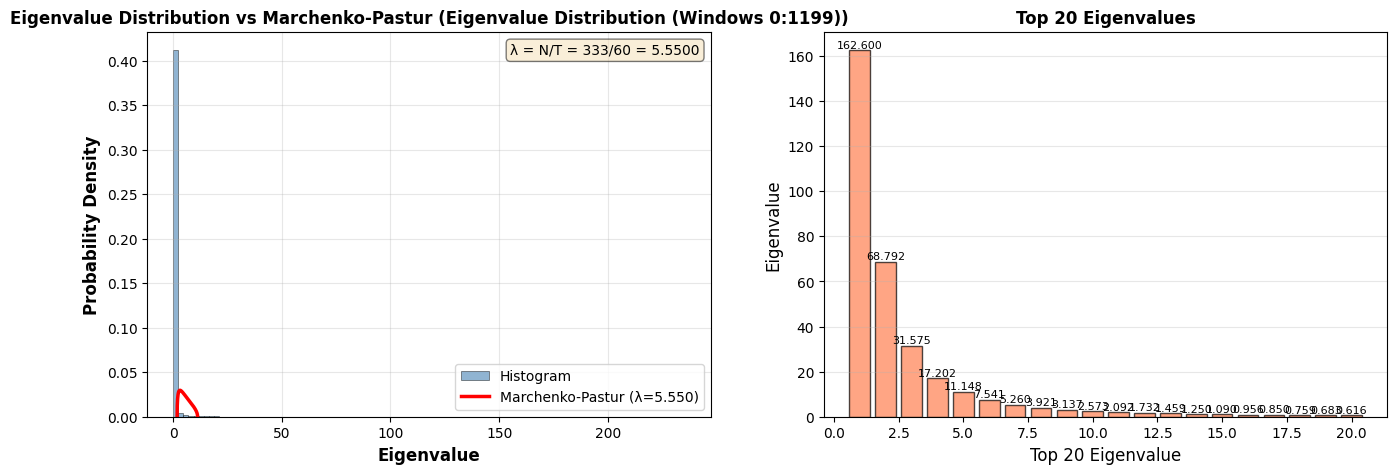

In [109]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()

# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

# Select data based on global choice
if selected_corr_matrix == 'all':
    data = eigenvalues_np.flatten()
    title = "Eigenvalue Distribution (All Windows)"
    selected_indices = np.arange(num_windows)
elif isinstance(selected_corr_matrix, str) and ':' in selected_corr_matrix:
    start_str, stop_str = selected_corr_matrix.split(':')
    start_idx, stop_idx = int(start_str), int(stop_str)
    if not (0 <= start_idx < stop_idx <= num_windows):
        raise ValueError(f"Invalid selected_corr_matrix range: {selected_corr_matrix}. Expected 'start:stop' with 0 <= start < stop <= {num_windows}.")
    selected_indices = np.arange(start_idx, stop_idx)
    data = eigenvalues_np[selected_indices].flatten()
    title = f"Eigenvalue Distribution (Windows {start_idx}:{stop_idx})"
else:
    matrix_idx = int(selected_corr_matrix)
    if not (0 <= matrix_idx < num_windows):
        raise ValueError(f"Invalid selected_corr_matrix index: {matrix_idx}. Valid range is [0, {num_windows - 1}].")
    selected_indices = np.array([matrix_idx])
    data = eigenvalues_np[matrix_idx]
    title = f"Eigenvalue Distribution (Matrix {matrix_idx})"

# Clip negative values to 0 (numerical errors in correlation matrices)
# Eigenvalues of correlation matrices should be non-negative
data = np.clip(data, 0, None)

# Calculate Marchenko-Pastur parameters
# lambda = number of assets / window length
lmbd = num_assets / window_length
sigma = 1.0

# Create histogram with density=True for probability density
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: Histogram with Marchenko-Pastur overlay
ax = axes[0]
n, bins, patches = ax.hist(data, bins=100, density=True, alpha=0.6,
                            color='steelblue', edgecolor='black', linewidth=0.5,
                            label='Histogram')

# Calculate Marchenko-Pastur bounds
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

# Create x range for theoretical curve (excluding top eigenvalues)
x_min = a
x_max = b

x_theory = np.linspace(x_min, x_max, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# Plot the theoretical Marchenko-Pastur density
ax.plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'Marchenko-Pastur (λ={lmbd:.3f})')

ax.set_xlabel('Eigenvalue', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title(f'Eigenvalue Distribution vs Marchenko-Pastur ({title})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add text annotation with lambda value
textstr = f'λ = N/T = {num_assets}/{window_length} = {lmbd:.4f}'
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right plot: Top eigenvalues as bar chart
ax = axes[1]
if len(selected_indices) == 1:
    eigenvalues = eigenvalues_np[selected_indices[0]]
else:
    # For all/range selections, show sorted mean eigenvalues
    eigenvalues = eigenvalues_np[selected_indices].mean(axis=0)

# Sort in descending order and take top values
top_k = min(20, len(eigenvalues))
top_eigenvalues = np.sort(eigenvalues)[::-1][:top_k]
ranks = np.arange(1, top_k + 1)

ax.bar(ranks, top_eigenvalues, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Top 20 Eigenvalue', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title(f'Top {top_k} Eigenvalues', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (rank, val) in enumerate(zip(ranks, top_eigenvalues)):
    ax.text(rank, val, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Print statistics
print(f"\n{'='*50}")
print(f"Statistics for {title}")
print(f"{'='*50}")
print(f"Count: {len(data)}")
print(f"Min: {np.min(data):.6f}")
print(f"Max: {np.max(data):.6f}")
print(f"\nMarchenko-Pastur bounds:")
print(f"  a (lower bound): {a:.6f}")
print(f"  b (upper bound): {b:.6f}")

# Identify eigenvalues above the Marchenko-Pastur limit (anomalies)
if len(selected_indices) == 1:
    eigenvalues_full = eigenvalues_np[selected_indices[0]]
else:
    eigenvalues_full = eigenvalues_np[selected_indices].mean(axis=0)

eigenvalues_above_b = eigenvalues_full[eigenvalues_full > b]

print(f"\nEigenvalues ABOVE Marchenko-Pastur limit (b={b:.6f}):")
if len(eigenvalues_above_b) > 0:
    for i, val in enumerate(sorted(eigenvalues_above_b, reverse=True), 1):
        print(f"  {i:2d}. {val:.6f}")
else:
    print("  (None)")

print(f"\nEigenvalues BELOW or WITHIN Marchenko-Pastur bounds: {len(eigenvalues_full) - len(eigenvalues_above_b)}")
print(f"{'='*50}\n")

### Explained Variance by Top-4 Eigenvalues

Analyze the cumulative explained variance captured by the first 4 eigenvalues. This shows what percentage of the total variance is explained by the largest eigenvalues across all correlation matrices.

--- Explained Variance by Top-4 Eigenvalues ---

Total windows analyzed: 1199

Statistics across all windows:
  λ₁ / Σλ:
    Mean: 0.4883
    Std:  0.0720
    Min:  0.3075
    Max:  0.7078

  (λ₁ + λ₂) / Σλ:
    Mean: 0.6949
    Std:  0.0619

  (λ₁ + λ₂ + λ₃) / Σλ:
    Mean: 0.7897
    Std:  0.0443

  (λ₁ + λ₂ + λ₃ + λ₄) / Σλ:
    Mean: 0.8413
    Std:  0.0328


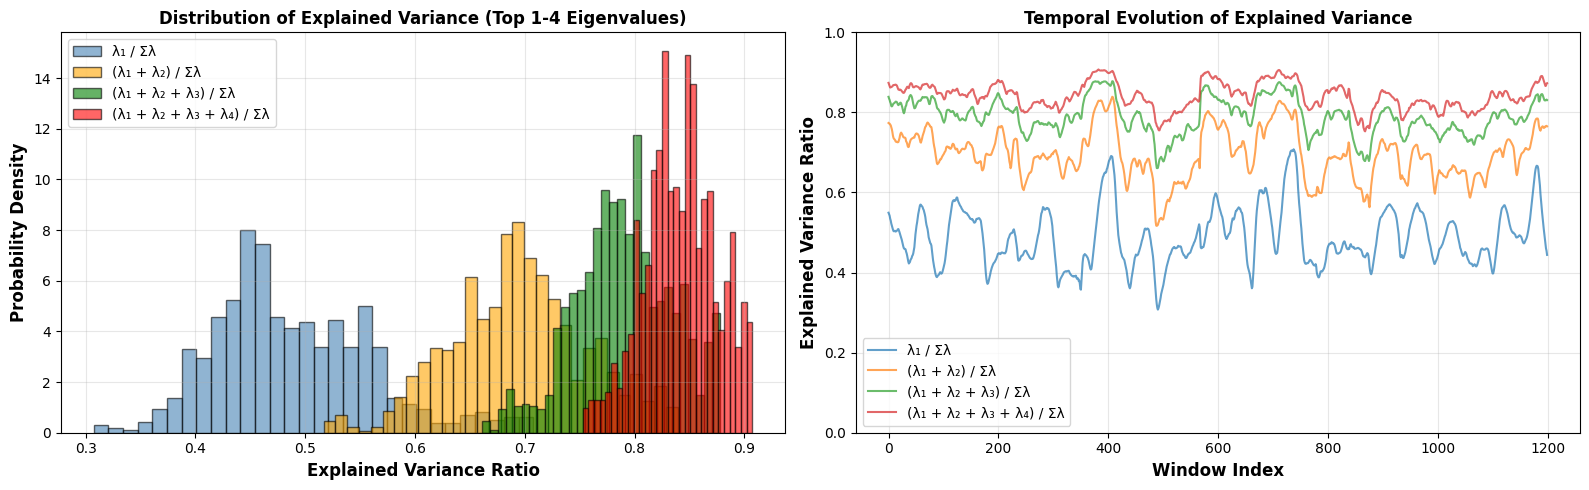


✓ Explained variance analysis complete!


In [110]:
# Compute cumulative explained variance for top-4 eigenvalues
def compute_explained_variance_top4(eigenvalues_np):
    """
    Compute the cumulative explained variance for the top 4 eigenvalues across all matrices.
    
    Parameters:
    -----------
    eigenvalues_np : np.ndarray
        Shape (num_matrices, num_eigenvalues), sorted in descending order
    
    Returns:
    --------
    explained_variance : np.ndarray
        Shape (num_matrices, 4) containing:
        - Column 0: λ₁ / Σλ
        - Column 1: (λ₁ + λ₂) / Σλ
        - Column 2: (λ₁ + λ₂ + λ₃) / Σλ
        - Column 3: (λ₁ + λ₂ + λ₃ + λ₄) / Σλ
    """
    num_matrices = eigenvalues_np.shape[0]
    explained_variance = np.empty((num_matrices, 4))
    
    for i in range(num_matrices):
        eigenvals = eigenvalues_np[i]
        total_sum = np.sum(eigenvals)
        
        # Compute cumulative sums of top 4 eigenvalues, normalized by total sum
        top4_cumsum = np.cumsum(eigenvals[:4])
        explained_variance[i, :] = top4_cumsum / total_sum
    
    return explained_variance


# Compute explained variance
explained_variance = compute_explained_variance_top4(eigenvalues_np)

print(f"--- Explained Variance by Top-4 Eigenvalues ---\n")
print(f"Total windows analyzed: {explained_variance.shape[0]}")
print(f"\nStatistics across all windows:")
print(f"  λ₁ / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 0]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 0]):.4f}")
print(f"    Min:  {np.min(explained_variance[:, 0]):.4f}")
print(f"    Max:  {np.max(explained_variance[:, 0]):.4f}")

print(f"\n  (λ₁ + λ₂) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 1]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 1]):.4f}")

print(f"\n  (λ₁ + λ₂ + λ₃) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 2]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 2]):.4f}")

print(f"\n  (λ₁ + λ₂ + λ₃ + λ₄) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 3]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 3]):.4f}")


# Visualization: Overlaid histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ===== Left Plot: Overlaid Histograms (Density) =====
ax = axes[0]
ax.hist(explained_variance[:, 0], bins=30, density=True, alpha=0.6, 
        label='λ₁ / Σλ', color='steelblue', edgecolor='black')
ax.hist(explained_variance[:, 1], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂) / Σλ', color='orange', edgecolor='black')
ax.hist(explained_variance[:, 2], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂ + λ₃) / Σλ', color='green', edgecolor='black')
ax.hist(explained_variance[:, 3], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂ + λ₃ + λ₄) / Σλ', color='red', edgecolor='black')

ax.set_xlabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Explained Variance (Top 1-4 Eigenvalues)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# ===== Right Plot: Time Series =====
ax = axes[1]
ax.plot(explained_variance[:, 0], alpha=0.7, linewidth=1.5, label='λ₁ / Σλ')
ax.plot(explained_variance[:, 1], alpha=0.7, linewidth=1.5, label='(λ₁ + λ₂) / Σλ')
ax.plot(explained_variance[:, 2], alpha=0.7, linewidth=1.5, label='(λ₁ + λ₂ + λ₃) / Σλ')
ax.plot(explained_variance[:, 3], alpha=0.7, linewidth=1.5, label='(λ₁ + λ₂ + λ₃ + λ₄) / Σλ')

ax.set_xlabel('Window Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax.set_title('Temporal Evolution of Explained Variance', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Explained variance analysis complete!")

### Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


Perron-Frobenius Property Analysis

Matrices #0 to #1198 (1199 total)
Satisfying Perron-Frobenius property: 0/1199 (0.0%)
All selected matrices have multiplicity = 1: True

Tickers with NEGATIVE mean component (1 total):
  124. MAT    -> -0.000891


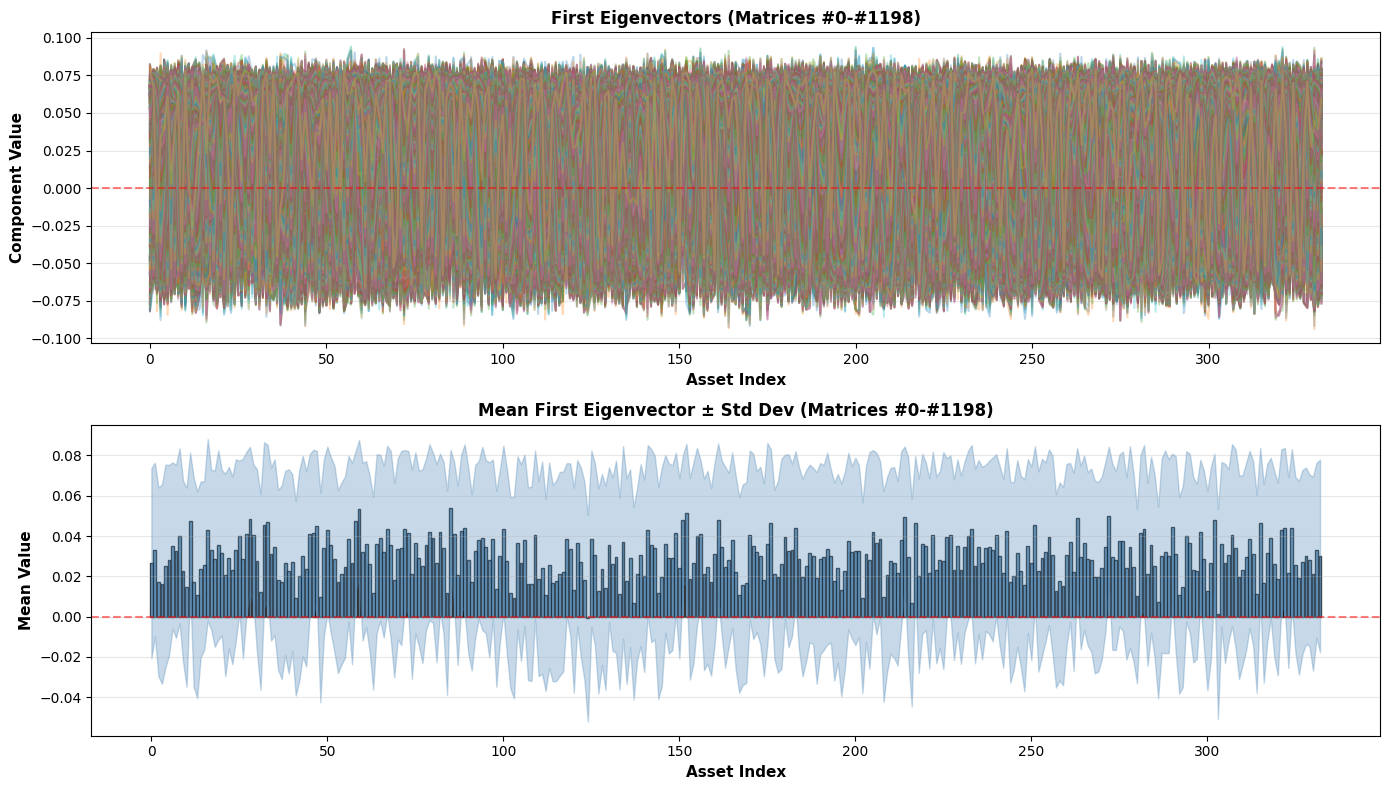

In [111]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()
eigenvectors_np = eigenvectors_tensor.cpu().numpy()

num_matrices = eigenvalues_np.shape[0]
num_assets = eigenvalues_np.shape[1]

# Parse global selection to determine analysis type and matrices
if selected_corr_matrix == 'all':
    matrix_indices = np.arange(num_matrices)
    analysis_type = 'all'
elif isinstance(selected_corr_matrix, str) and ':' in selected_corr_matrix:
    parts = selected_corr_matrix.split(':')
    start_idx, stop_idx = int(parts[0]), int(parts[1])
    if not (0 <= start_idx < stop_idx <= num_matrices):
        raise ValueError(f"Invalid selected_corr_matrix range: {selected_corr_matrix}. Expected 'start:stop' with 0 <= start < stop <= {num_matrices}.")
    matrix_indices = np.arange(start_idx, stop_idx)
    analysis_type = 'range'
else:
    matrix_idx = int(selected_corr_matrix)
    if not (0 <= matrix_idx < num_matrices):
        raise ValueError(f"Invalid selected_corr_matrix index: {matrix_idx}. Valid range is [0, {num_matrices - 1}].")
    matrix_indices = np.array([matrix_idx])
    analysis_type = 'single'

# Pre-compute eigenvectors and properties for ALL matrices
pf_property_check = np.zeros(num_matrices, dtype=bool)
first_eigenvectors = np.full((num_assets, num_matrices), np.nan)
max_eigenvalue_multiplicity = np.zeros(num_matrices, dtype=int)

for i in range(num_matrices):
    eigenvalues = eigenvalues_np[i]
    eigenvectors = eigenvectors_np[i]

    # Get first eigenvector (largest eigenvalue)
    first_eigenvector = eigenvectors[:, 0].copy()

    # Normalize sign using sum (more robust than first element)
    if np.sum(first_eigenvector) < 0:
        first_eigenvector = -first_eigenvector

    first_eigenvectors[:, i] = first_eigenvector
    pf_property_check[i] = np.all(first_eigenvector >= -1e-2)
    max_eigenvalue_multiplicity[i] = np.sum(np.isclose(eigenvalues[0], eigenvalues, atol=1e-6))




def print_negative_tickers(vector, tickers, use_mean_label):
    neg_idx = np.where(vector < 0)[0]
    if len(neg_idx) > 0:
        label = 'mean component' if use_mean_label else 'components'
        print(f"\nTickers with NEGATIVE {label} ({len(neg_idx)} total):")
        for idx in neg_idx:
            print(f"  {idx:3d}. {tickers[idx]:6s} -> {vector[idx]:8.6f}")
    else:
        print("\nNo tickers with negative values")

def plot_property3_single(eigvec, title):
    """Render a simple histogram for a single matrix eigenvector."""
    fig, ax = plt.subplots(figsize=(14, 6))
    asset_idx = np.arange(num_assets)
    
    ax.bar(asset_idx, eigvec, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    ax.set_ylabel('Component Value', fontsize=11, fontweight='bold')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

def plot_property3_panels(first_panel_data, first_panel_title, mean_vec, std_vec, second_panel_title):
    """Render the two required plots for Property 3 without duplicating plotting code."""
    _, axes = plt.subplots(2, 1, figsize=(14, 8))
    asset_idx = np.arange(num_assets)

    # First panel: always overlay.
    for vec in first_panel_data:
        axes[0].plot(vec, alpha=0.3)

    axes[0].set_title(first_panel_title, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Component Value', fontsize=11, fontweight='bold')
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Second panel: always mean ± std.
    axes[1].bar(asset_idx, mean_vec, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].fill_between(asset_idx, mean_vec - std_vec, mean_vec + std_vec, alpha=0.3, color='steelblue')
    axes[1].set_title(second_panel_title, fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean Value', fontsize=11, fontweight='bold')
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# ===== ANALYSIS OUTPUT =====
print(f"\n{'='*60}")
print("Perron-Frobenius Property Analysis")
print(f"{'='*60}")

subset_indices = matrix_indices
subset_vec = first_eigenvectors[:, subset_indices]
subset_pf = pf_property_check[subset_indices]
subset_mult = max_eigenvalue_multiplicity[subset_indices]
num_selected = len(subset_indices)
num_satisfying = np.sum(subset_pf)

if analysis_type == 'single':
    matrix_idx = subset_indices[0]
    eigvec = subset_vec[:, 0]

    print(f"\nMatrix #{matrix_idx}:")
    print(f"  Perron-Frobenius property satisfied: {subset_pf[0]}")
    print(f"  Largest eigenvalue multiplicity: {int(subset_mult[0])}")
    print(f"  Min component: {np.min(eigvec):.6f}, Max component: {np.max(eigvec):.6f}")

    print_negative_tickers(eigvec, tickers, use_mean_label=False)

    plot_property3_single(eigvec, f'First Eigenvector (Matrix #{matrix_idx})')

else:
    mean_vec = np.mean(subset_vec, axis=1)
    std_vec = np.std(subset_vec, axis=1)

    if analysis_type == 'all':
        print(f"\nMatrices satisfying Perron-Frobenius property: {num_satisfying}/{num_matrices} ({100*num_satisfying/num_matrices:.1f}%)")
        print(f"All matrices have multiplicity = 1: {np.all(subset_mult == 1)}")
        first_panel_title = 'First Eigenvectors (All Matrices)'
        second_panel_title = 'Mean First Eigenvector ± Std Dev (All Matrices)'
    else:
        print(f"\nMatrices #{subset_indices[0]} to #{subset_indices[-1]} ({num_selected} total)")
        print(f"Satisfying Perron-Frobenius property: {num_satisfying}/{num_selected} ({100*num_satisfying/num_selected:.1f}%)")
        print(f"All selected matrices have multiplicity = 1: {np.all(subset_mult == 1)}")
        first_panel_title = f'First Eigenvectors (Matrices #{subset_indices[0]}-#{subset_indices[-1]})'
        second_panel_title = f'Mean First Eigenvector ± Std Dev (Matrices #{subset_indices[0]}-#{subset_indices[-1]})'

    print_negative_tickers(mean_vec, tickers, use_mean_label=True)

    first_panel_data = [subset_vec[:, j] for j in range(num_selected)]

    plot_property3_panels(
        first_panel_data=first_panel_data,
        first_panel_title=first_panel_title,
        mean_vec=mean_vec,
        std_vec=std_vec,
        second_panel_title=second_panel_title,
    )